In [2]:
!module purge
!module load python/3.10.13-fasrc01
!python --version

Python 3.10.13


In [ ]:
!python -m pip install ipykernel
!python -m ipykernel install --user --name=python310 --display-name "Python 3.10 (fasrc01)"

In [1]:
!module load python/3.10.13-fasrc01
import sys, google.generativeai as genai
print(sys.version)
print(genai.__version__)


3.10.13 | packaged by conda-forge | (main, Oct 26 2023, 18:07:37) [GCC 12.3.0]
0.8.5


/n/sw/Mambaforge-23.11.0-0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
!pip3 install pandas

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 18.1 MB/s eta 0:00:00
  Created wheel for fasttext: filename=fasttext-0.9.3-cp310-cp310-linux_x86_64.whl size=330329 sha256=6b9842ba72a2be713ac38cce5e688252e46be5d6ef617cb92ee6f50fc91814bf
  Stored in directory: /tmp/pip-ephem-wheel-cache-ux4p2xj9/wheels/0d/a2/00/81db54d3e6a8199b829d58e02cec2ddb20ce3e59fad8d3c92a
Successfully built fasttext
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import os
import gzip
import glob
import re
import pandas as pd
from multiprocessing import Pool, cpu_count
import fasttext
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_ROOT = "/n/holylabs/LABS/cga/Lab/data/geo-tweets/cga-sbg-tweets/"
OUTPUT_DIR = "/n/netscratch/cga/Everyone/zifu/ageism/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FASTTEXT_PATH = "/n/netscratch/cga/Everyone/zifu/lid.176.bin"
YEARS = list(range(2014, 2015))
NUM_CORES = 20  # Max cores for high performance (FASRC optimized)

# -----------------------------
# KEYWORDS
# -----------------------------
# Exact match keywords (single words or fixed multi-word phrases)
exact_keywords = [
    # Word List A (Older persons terms)
    "the old", "senior citizens", "seniors", "boomers", "baby boomers", "aged", "aging",
    "retirees", "retired", "retirement", "grandparents", "grandma", "grandpa", "grandmother",
    "grandfather", "grandad", "grandmom", "Gramps", "Gramma", "Grammie", "granny", "paw paw",
    "nonnie", "noni", "zadie", "zady", "bubbie", "bubby", "silver generation", "social security",
    "pensioner", "Elderly", "elderly person", "elder", "geriatric", "golden-ager", "OAP",
    "Old Age Pensioner", "old fogy", "old-age pensioner", "old-timer", "patriarch", "matriarch",
    "veteran", "elder statesman", "elder stateswoman", "oldster", "oldie", "doyenne", "doyen",
    "ancestor", "antique", "nursing home", "assisted living", "carehome", "gerontocracy",
    "Whippersnapper", "long-lived", "superannuated", "unyounge", "overaged", "pensioned",
    "in one's dotage", "advanced age", "old as Methuselah", "antediluvian", "wrinkly",
    "wrinkie", "curmudgeon", "beekeeping age", "dinosaur", "geezer", "fuddy-duddy", "fossil",
    "coot", "codger", "OK boomer", "Has-been", "old fart", "silver fox", "old hag", "wrinkles",
    "gray hair", "white hair", "blue hair", "silver hair", "saggy", "hump backed", "pops",
    "pop", "pop pop", "sexagenarian", "septuagenarian", "octogenarian", "nonagenarian",
    "centenarian", "super centenarian",

]

# Wildcard keywords (root forms only, no *)
wildcard_keywords = [
    
]


# Compile non-capturing regex pattern
regex_pattern = re.compile(
    r"\b(?:" +
    "|".join([f"{kw}\\w*" for kw in wildcard_keywords] + exact_keywords) +
    r")\b",
    flags=re.IGNORECASE
)

# -----------------------------
# DISPLAY KEYWORDS USED
# -----------------------------
print("\n📋 Keywords included in the regex search:")
print("🔹 Wildcard keywords (prefix search):")
print([f"{kw}\\w*" for kw in wildcard_keywords])
print("\n🔸 Exact match keywords:")
print(exact_keywords)


📋 Keywords included in the regex search:
🔹 Wildcard keywords (prefix search):
[]

🔸 Exact match keywords:
['the old', 'senior citizens', 'seniors', 'boomers', 'baby boomers', 'aged', 'aging', 'retirees', 'retired', 'retirement', 'grandparents', 'grandma', 'grandpa', 'grandmother', 'grandfather', 'grandad', 'grandmom', 'Gramps', 'Gramma', 'Grammie', 'granny', 'paw paw', 'nonnie', 'noni', 'zadie', 'zady', 'bubbie', 'bubby', 'silver generation', 'social security', 'pensioner', 'Elderly', 'elderly person', 'elder', 'geriatric', 'golden-ager', 'OAP', 'Old Age Pensioner', 'old fogy', 'old-age pensioner', 'old-timer', 'patriarch', 'matriarch', 'veteran', 'elder statesman', 'elder stateswoman', 'oldster', 'oldie', 'doyenne', 'doyen', 'ancestor', 'antique', 'nursing home', 'assisted living', 'carehome', 'gerontocracy', 'Whippersnapper', 'long-lived', 'superannuated', 'unyounge', 'overaged', 'pensioned', "in one's dotage", 'advanced age', 'old as Methuselah', 'antediluvian', 'wrinkly', 'wrinkie

In [3]:
def load_fasttext_model():
    global model
    model = fasttext.load_model(FASTTEXT_PATH)

# Language detection (no text length restriction)
def is_english(text):
    try:
        text = text.strip().replace("\n", "")
        return model.predict(text)[0][0] == '__label__en'
    except:
        return False

# -----------------------------
# FILE PROCESSING FUNCTION
# -----------------------------
def process_file(file_path):
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f, sep='\t', on_bad_lines="skip", dtype=str)

        if 'text' not in df.columns:
            return pd.DataFrame()

        df = df.dropna(subset=["text"])
        df = df[df["text"].str.contains(regex_pattern, na=False, regex=True)]
        df = df[df["text"].apply(is_english)]
        return df

    except Exception as e:
        print(f"⚠️ Error in {os.path.basename(file_path)}: {e}")
        return pd.DataFrame()

In [ ]:
# 🚀 Block 3 — Yearly Extraction (Auto-run for 2010–2023) — v6

from time import time
from tqdm import tqdm

# Define quarterly bins
QUARTERS = {
    "Q3": [7, 8, 9],
    "Q4": [10, 11, 12],
}

def extract_month(file_path):
    """Extract the month from filename like '2013_11_09_10.csv.gz'"""
    match = re.search(r"\d{4}_(\d{1,2})_\d{1,2}_\d{1,2}", os.path.basename(file_path))
    return int(match.group(1)) if match else None

def run_quarter(year, quarter, months):
    input_dir = os.path.join(DATA_ROOT, str(year))
    output_path = os.path.join(OUTPUT_DIR, f"filtered_tweets_{year}_{quarter}.csv.gz")

    if not os.path.exists(input_dir):
        print(f"⚠️ Skipping {year}-{quarter} — input folder not found: {input_dir}", flush=True)
        return

    all_files = glob.glob(os.path.join(input_dir, "*.csv.gz"))

    # Filter files by month using regex
    files = [f for f in all_files if extract_month(f) in months]

    if not files:
        print(f"⚠️ Skipping {year}-{quarter} — no files matched.", flush=True)
        return

    print(f"\n🚀 Processing {year} {quarter} — {len(files)} files", flush=True)

    start = time()
    with Pool(processes=NUM_CORES, initializer=load_fasttext_model) as pool:
        results = list(tqdm(pool.imap_unordered(process_file, files), total=len(files)))

    filtered_df = pd.concat(results, ignore_index=True)
    filtered_df.to_csv(output_path, index=False, compression="gzip")

    duration = time() - start
    print(f"\n✅ Done: {year} {quarter} — {len(filtered_df):,} tweets")
    print(f"🕒 Duration: {duration:.2f} seconds")
    print(f"📁 Saved to: {output_path}\n")

# ✅ Full run over quarters
for year in YEARS:
    for quarter, months in QUARTERS.items():
        run_quarter(year, quarter, months)


In [ ]:
import pandas as pd
import os

# Set directory and output path
input_dir = "/n/netscratch/cga/Everyone/zifu/ageism"
output_path = os.path.join(input_dir, "filtered_tweets_2014.csv.gz")

# Define quarterly files
quarter_files = [
    os.path.join(input_dir, "filtered_tweets_2014_Q1.csv.gz"),
    os.path.join(input_dir, "filtered_tweets_2014_Q2.csv.gz"),
    os.path.join(input_dir, "filtered_tweets_2014_Q3.csv.gz"),
    os.path.join(input_dir, "filtered_tweets_2014_Q4.csv.gz"),
]

# Load and concatenate
dfs = [pd.read_csv(f) for f in quarter_files]
merged_df = pd.concat(dfs, ignore_index=True)

# Save merged file
merged_df.to_csv(output_path, index=False, compression="gzip")

print(f"✅ Merged 2014 tweet data saved to: {output_path}")
print(f"📝 Total tweets: {len(merged_df):,}")


In [2]:
import pandas as pd
import glob
import os

# -----------------------------
# CONFIG
# -----------------------------
INPUT_DIR = "/n/netscratch/cga/Everyone/zifu/ageism"  # folder where your files are
OUTPUT_FILE = "filtered_tweets_2014_classified.csv.gz"

# -----------------------------
# LOAD AND MERGE
# -----------------------------
# Grab all Q1–Q4 files
files = sorted(glob.glob(os.path.join(INPUT_DIR, "filtered_tweets_2014_Q*_classified.csv.gz")))

dfs = []
for f in files:
    print("Loading:", f)
    df = pd.read_csv(f, compression="gzip", low_memory=False)
    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

# -----------------------------
# SAVE
# -----------------------------
merged_df.to_csv(OUTPUT_FILE, index=False, compression="gzip")
print("Merged file saved as:", OUTPUT_FILE)


Loading: /n/netscratch/cga/Everyone/zifu/ageism/filtered_tweets_2014_Q1_classified.csv.gz
Loading: /n/netscratch/cga/Everyone/zifu/ageism/filtered_tweets_2014_Q2_classified.csv.gz
Loading: /n/netscratch/cga/Everyone/zifu/ageism/filtered_tweets_2014_Q3_classified.csv.gz
Loading: /n/netscratch/cga/Everyone/zifu/ageism/filtered_tweets_2014_Q4_classified.csv.gz
Merged file saved as: filtered_tweets_2014_classified.csv.gz


In [3]:
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
INPUT_FILE = "filtered_tweets_2014_classified.csv.gz"
OUTPUT_FILE = "filtered_tweets_2014_classified_relevant.csv.gz"

# -----------------------------
# LOAD
# -----------------------------
df = pd.read_csv(INPUT_FILE, compression="gzip", low_memory=False)

# -----------------------------
# FILTER OUT "Not relevant"
# -----------------------------
total_rows = len(df)
not_relevant_rows = (df["classification"] == "Not relevant").sum()

print(f"Total rows before filtering: {total_rows}")
print(f"Number of 'Not relevant' rows: {not_relevant_rows}")
print(f"Rows after filtering: {total_rows - not_relevant_rows}")

# Save filtered version
df_relevant = df[df["classification"] != "Not relevant"]
df_relevant.to_csv(OUTPUT_FILE, index=False, compression="gzip")

print("Filtered file saved as:", OUTPUT_FILE)


Total rows before filtering: 3517191
Number of 'Not relevant' rows: 1606167
Rows after filtering: 1911024
Filtered file saved as: filtered_tweets_2014_classified_relevant.csv.gz


In [ ]:
from time import time

def summarize_extraction(output_folder):
    print("\n────────────────────────────────────── 📊 FINAL SUMMARY ──────────────────────────────────────", flush=True)

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))
    total_tweets = 0
    summary = []

    for file in files:
        year = os.path.basename(file).split("_")[-1].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression='gzip', dtype=str, usecols=["text"])
            count = len(df)
            summary.append((year, count))
            total_tweets += count
            print(f"📅 Year {year}: {count:,} tweets", flush=True)
        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    print("\n✅ Extraction complete across", len(files), "years.", flush=True)
    print(f"🔢 Total tweets extracted: {total_tweets:,}\n", flush=True)

# ✅ Auto-run summary after extraction
start_summary = time()
summarize_extraction(OUTPUT_DIR)
print(f"🕒 Summary generated in {time() - start_summary:.2f} seconds.\n", flush=True)

In [ ]:
from openai import OpenAI
import pandas as pd
import os
import json
import re
import time

# -----------------------------
# LLM Client Setup
# -----------------------------
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
model_name = "google/gemma-3-1b"

INPUT_FILE = "filtered_tweets_2014_Q4.csv.gz"
OUTPUT_FILE = "filtered_tweets_2014_Q4_classified.csv.gz"

# -----------------------------
# JSON Schema for classification
# -----------------------------
classification_schema = {
    "type": "json_schema",
    "json_schema": {
        "name": "AgeismClassification",
        "schema": {
            "type": "object",
            "properties": {
                "classification": {
                    "type": "string",
                    "enum": ["Not relevant", "Ageist", "Age-positive"]
                }
            },
            "required": ["classification"]
        },
    }
}

# -----------------------------
# Load input
# -----------------------------
df = pd.read_csv(INPUT_FILE, compression="gzip", dtype=str)
df["classification"] = ""

# -----------------------------
# Loop through tweets
# -----------------------------
for i, row in df.iterrows():
    start_time = time.time()
    text = row["text"]  # make sure your tweet text column is called "text"

    prompt_text = f"""
    You are an assistant analyzing social media posts for age-related content.  
    Your task is to classify each post into one of three categories:

    1. "Not relevant" – if the post is not related to age, aging, or ageism.  

    2. "Ageist" – if the post contains any negative, harmful, or stereotypical language about aging or older adults.  
       Examples and keywords include (but are not limited to):  
       alone, loneliness, isolated, diseased, decrepit, infirm, confused, forgetful, memory loss, misplaces, dying, waiting to die, retire already, time to go, dementia, senile, senility, incompetent, dependent, decline, alzheimer's, deteriorated, shaky, wrinkled, grumpy, cranky, given up, walks slowly, slow, helpless, aches and pains, frail, fragile, weak, vulnerable, not tech-savvy, technophobe, technologically challenged, outdated, stuck in the past, old-fashioned, out-of-touch, can't learn, can't change, despondent, impaired, shrew, curmudgeon, complaining, ill-tempered, recluse, timid, naïve, nosy neighbor, put someone out to pasture, losing it, bag lady, rigid, feeble, irrelevant, doddering, fossil, geezer, fuddy-duddy, coot, old fart, old hag, has-been, advanced age, old as Methuselah, antediluvian.  

    3. "Age-positive" – if the post highlights positive qualities of aging or older adults.  
       Examples and keywords include (but are not limited to):  
       astute, insightful, enlightened, creative, advise, improving, learned, accomplished, sage, alert, guidance, wise, wisdom, wiser, family-oriented, capable, active, positive outlook, well-groomed, will-to-live, full of life, more freedom and time for new interests, continue to grow as a person, appreciate things more, nurturing, warm, caring, kind, loving, respected, honored, role model, mentor, family anchor, legacy, heritage, golden years, aging gracefully, graceful aging, patriotic, nostalgic, embrace aging, age positivity, experienced, venerable, mature, spry, zesty, feisty, spirited.  

    Return only a single category label:  
    "Not relevant", "Ageist", or "Age-positive".

    Post: {text}
    """

    # LLM call
    response = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": [{"type": "text", "text": prompt_text.strip()}]}],
        response_format=classification_schema,
    )

    raw = response.choices[0].message.content.strip()
    #print(f"🏷️ LLM output raw: {raw}")

    # Parse JSON safely
    try:
        parsed = json.loads(raw)
        classification = parsed.get("classification", "Not relevant")
    except Exception:
        classification = "Not relevant"

    df.at[i, "classification"] = classification

    print(f"\n📄 Tweet {i+1} of {len(df)}")
    print(f"🏷️ Classification: {classification}")
    #print(f"⏱️ Runtime: {round(time.time() - start_time, 2)} seconds")

# -----------------------------
# Save output
# -----------------------------
df.to_csv(OUTPUT_FILE, index=False, compression="gzip")
print(f"\n✅ Done. Saved to {OUTPUT_FILE}")


E0000 00:00:1758339364.341588  695576 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 1/1045385 → Not relevant ⏱ 1.2s
Raw: ```json
{
  "classification": "Ageist"
}
```
Tweet 2/1045385 → Not relevant ⏱ 0.93s
Raw: ```json
{
  "classification": "Ageist"
}
```
Tweet 3/1045385 → Not relevant ⏱ 1.03s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 4/1045385 → Not relevant ⏱ 0.96s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 5/1045385 → Not relevant ⏱ 1.07s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 6/1045385 → Not relevant ⏱ 1.1s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 7/1045385 → Not relevant ⏱ 1.11s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 8/1045385 → Not relevant ⏱ 1.15s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 9/1045385 → Not relevant ⏱ 1.01s
Raw: ```json
{
  "classification": "Not relevant"
}
```
Tweet 10/1045385 → Not relevant ⏱ 1.08s
Raw: ```json
{
  "classification": "Ageist"
}
```
Tweet 11/1045

ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_paid_tier_input_token_count, limit: 15000
Please retry in 27.855743736s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_paid_tier_input_token_count"
  quota_id: "GenerateContentPaidTierInputTokensPerModelPerMinute"
  quota_dimensions {
    key: "model"
    value: "gemma-3-4b"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15000
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 27
}
]


────────────────────────────── SUMMARY ──────────────────────────────
🔢 Total tweets: 3,517,191
🚫 'Not relevant': 1,606,167 (45.67%)
⚠️ 'Ageist': 1,029,629 (29.27%)
💬 'Age-positive': 881,395 (25.06%)


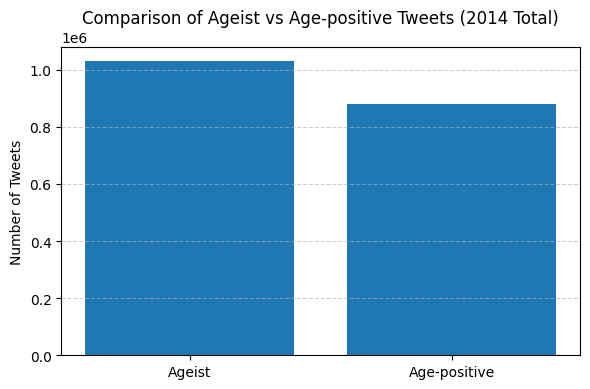

In [14]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# Folder path
folder = "/n/netscratch/cga/Everyone/zifu/ageism/raw_data"

# Find all quarterly files
files = sorted(glob.glob(os.path.join(folder, "filtered_tweets_2014_Q*_classified.csv.gz")))

total_tweets = 0
count_not_relevant = 0
count_ageist = 0
count_age_positive = 0

# Loop through all quarterly files and aggregate
for file in files:
    try:
        df = pd.read_csv(file, compression="gzip", dtype=str)

        if "classification" not in df.columns:
            print(f"⚠️ Skipping {file}: no 'classification' column found.")
            continue

        total_tweets += len(df)
        count_not_relevant += (df["classification"].str.strip() == "Not relevant").sum()
        count_ageist += (df["classification"].str.strip() == "Ageist").sum()
        count_age_positive += (df["classification"].str.strip() == "Age-positive").sum()

    except Exception as e:
        print(f"⚠️ Error reading {file}: {e}")

# Compute percentages
pct_not_relevant = count_not_relevant / total_tweets * 100 if total_tweets else 0
pct_ageist = count_ageist / total_tweets * 100 if total_tweets else 0
pct_age_positive = count_age_positive / total_tweets * 100 if total_tweets else 0

# Print summary
print("\n────────────────────────────── SUMMARY ──────────────────────────────")
print(f"🔢 Total tweets: {total_tweets:,}")
print(f"🚫 'Not relevant': {count_not_relevant:,} ({pct_not_relevant:.2f}%)")
print(f"⚠️ 'Ageist': {count_ageist:,} ({pct_ageist:.2f}%)")
print(f"💬 'Age-positive': {count_age_positive:,} ({pct_age_positive:.2f}%)")

# Plot histogram
labels = ["Ageist", "Age-positive",'Not relevant']
values = [count_ageist, count_age_positive,count_not_relevant]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title("Comparison of Ageist vs Age-positive Tweets (2014 Total)")
plt.ylabel("Number of Tweets")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


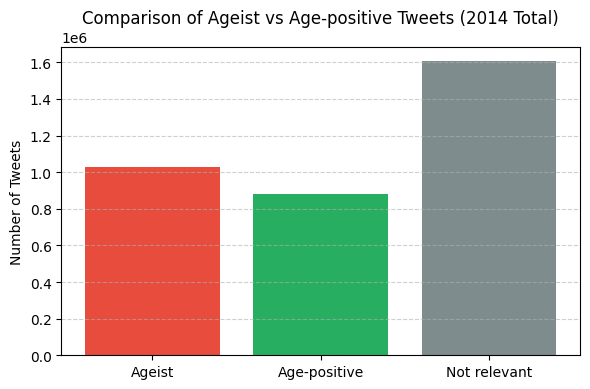

✅ Histogram saved to: /n/netscratch/cga/Everyone/zifu/ageism/ageism_histogram_2014.png


In [28]:
# Plot histogram
labels = ["Ageist", "Age-positive", "Not relevant"]
values = [count_ageist, count_age_positive, count_not_relevant]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["#E74C3C", "#27AE60", "#7F8C8D"])
plt.title("Comparison of Ageist vs Age-positive Tweets (2014 Total)")
plt.ylabel("Number of Tweets")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# 💾 Save as PNG
output_path = "/n/netscratch/cga/Everyone/zifu/ageism/ageism_histogram_2014.png"
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

print(f"✅ Histogram saved to: {output_path}")


In [20]:
# 🚀 Block 5 — Semantic Validation Sample (Auto-run) — v7

import random
from collections import Counter
import pandas as pd
import os, glob

# -----------------------------
# CONFIGURATION
# -----------------------------
SAMPLE_SIZE_PER_YEAR = 125
SAMPLE_OUTPUT = os.path.join(OUTPUT_DIR, "sample_semantic_validation.csv")
folder = "/n/netscratch/cga/Everyone/zifu/ageism/raw_data"

# -----------------------------
# FUNCTION
# -----------------------------
def generate_sample(output_folder, sample_size):
    print("\n──────────────────────────────────── 📦 GENERATING SEMANTIC SAMPLE ─────────────────────────────────────", flush=True)
    samples = []
    term_counter = Counter()

    files = sorted(glob.glob(os.path.join(folder, "filtered_tweets_2014_Q*_classified.csv.gz")))

    for file in files:
        year = os.path.basename(file).split("_")[-3].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "text" not in df.columns or df.empty:
                print(f"⚠️ Skipping {year}: No valid text found.", flush=True)
                continue

            if "classification" not in df.columns:
                print(f"⚠️ Skipping {year}: No 'classification' column found.", flush=True)
                continue

            n_samples = min(sample_size, len(df))
            df_sample = df.sample(n=n_samples, random_state=42)

            for _, row in df_sample.iterrows():
                text = str(row.get("text", ""))
                classification = str(row.get("classification", ""))
                found_terms = regex_pattern.findall(text)
                terms_detected = ", ".join(sorted(set(found_terms)))
                term_counter.update(t.lower() for t in found_terms)

                samples.append({
                    "year": year,
                    "classification": classification,
                    "text": text,
                    "terms_detected": terms_detected
                })

            print(f"📅 Sampled {n_samples} tweets for year {year}.", flush=True)

        except Exception as e:
            print(f"⚠️ Error sampling {year}: {e}", flush=True)

    if samples:
        pd.DataFrame(samples).to_csv(SAMPLE_OUTPUT, index=False)
        print(f"\n✅ Sample saved to: {SAMPLE_OUTPUT}", flush=True)
        print(f"🔢 Total sample size: {len(samples):,} tweets", flush=True)
    else:
        print("\n⚠️ No samples generated.", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_sample(OUTPUT_DIR, SAMPLE_SIZE_PER_YEAR)



──────────────────────────────────── 📦 GENERATING SEMANTIC SAMPLE ─────────────────────────────────────
📅 Sampled 125 tweets for year 2014.
📅 Sampled 125 tweets for year 2014.
📅 Sampled 125 tweets for year 2014.
📅 Sampled 125 tweets for year 2014.

✅ Sample saved to: /n/netscratch/cga/Everyone/zifu/ageism/sample_semantic_validation.csv
🔢 Total sample size: 500 tweets


In [21]:
# 🚀 Block 5.1 — Preview Semantic Sample (Optional Display)

import pandas as pd

print("\n──────────────────────────────────── 🔍 SEMANTIC SAMPLE PREVIEW ─────────────────────────────────────", flush=True)

try:
    df_sample = pd.read_csv(SAMPLE_OUTPUT)
    display_cols = ["year", "classification", "terms_detected", "text"]
    print(df_sample[display_cols].head(10).to_string(index=False))
    print(f"\n🟢 Displaying 10 of {len(df_sample):,} sampled tweets.")
except Exception as e:
    print(f"⚠️ Failed to load semantic sample: {e}")


──────────────────────────────────── 🔍 SEMANTIC SAMPLE PREVIEW ─────────────────────────────────────
 year classification terms_detected                                                                                                                                    text
 2014         Ageist        the old                                                                                                    Out with the old, in with the new 💨💨
 2014   Not relevant        grandma                                                                           @mackmancini ill ask my grandma to barrow her bingo dabbers 😂
 2014         Ageist        elderly                                                                                       Job description: babysit the elderly.  😒🔫    🚫👴👵🎰
 2014   Not relevant           pops                                                              Wowwww so were getting a car wash and kevs tire just pops..like k now what
 2014   Not relevant            pop   

In [ ]:
# 🚀 Block 6 — Keyword Frequency Analysis (Auto-run) — v6

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_OUTPUT = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year.csv")

# -----------------------------
# FUNCTION
# -----------------------------
def generate_keyword_frequencies(output_folder):
    print("\n──────────────────────────────────── 📈 GENERATING KEYWORD FREQUENCIES ─────────────────────────────────────", flush=True)
    all_counts = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        year = os.path.basename(file).split("_")[-3].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "text" not in df.columns or df.empty:
                print(f"⚠️ Skipping {year}: No valid text found.", flush=True)
                continue

            year_counter = Counter()

            for text in df["text"].dropna():
                found_terms = regex_pattern.findall(str(text))
                year_counter.update([term.lower() for term in found_terms])

            for term, count in year_counter.items():
                all_counts.append({
                    "year": year,
                    "term": term,
                    "count": count
                })

            print(f"📅 Counted terms for year {year}.", flush=True)

        except Exception as e:
            print(f"⚠️ Error processing {year}: {e}", flush=True)

    if all_counts:
        freq_df = pd.DataFrame(all_counts)
        freq_df = freq_df.sort_values(["year", "term"]).reset_index(drop=True)
        freq_df.to_csv(FREQ_OUTPUT, index=False)
        print(f"\n✅ Keyword frequencies saved to: {FREQ_OUTPUT}", flush=True)
    else:
        print("\n⚠️ No keyword counts generated.", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_keyword_frequencies(OUTPUT_DIR)


──────────────────────────────────── 📈 GENERATING KEYWORD FREQUENCIES ─────────────────────────────────────
📅 Counted terms for year 2014.

✅ Keyword frequencies saved to: /n/netscratch/cga/Everyone/zifu/ageism/keyword_frequencies_by_year.csv


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_FILE = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year.csv")
TOP_TERMS_TO_PLOT = [
    "senile", "decrepit", "burden", "old fart", "put someone out to pasture",
    "technologically challenged", "waiting to die", "frail", "OK boomer",
    "losing it", "has-been", "fossil"
]
MIN_YEAR = 2013
MAX_YEAR = 2025

# -----------------------------
# FUNCTION
# -----------------------------
def plot_keyword_trends(freq_file):
    print("\n──────────────────────────────────── 📊 PLOTTING TRENDS ─────────────────────────────────────", flush=True)

    try:
        df = pd.read_csv(freq_file, dtype=str)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

        # Filter years of interest
        df = df[(df["year"] >= MIN_YEAR) & (df["year"] <= MAX_YEAR)]

        # Create pivot for heatmap
        pivot_df = df.pivot_table(index="term", columns="year", values="count", fill_value=0)

        # -----------------------------
        # 📈 Line Chart
        # -----------------------------
        plt.figure(figsize=(14, 7))
        for term in TOP_TERMS_TO_PLOT:
            subset = df[df["term"] == term.lower()]
            if subset.empty:
                continue  # Skip if the term is not found
            plt.plot(subset["year"].values, subset["count"].values, marker='o', label=term.capitalize())

        plt.title("📈 Ageism Terms — Trend Over Time", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Mentions", fontsize=14)
        plt.legend()
        available_years = sorted(df["year"].unique())
        plt.xticks(ticks=available_years, fontsize=12)
        plt.grid(True)
        plt.tight_layout()

        # 💾 Save line chart as PNG
        line_chart_path = os.path.join(OUTPUT_DIR, "ageism_trend_linechart.png")
        plt.savefig(line_chart_path, dpi=300)
        print(f"✅ Line chart saved: {line_chart_path}", flush=True)

        plt.close()  # Close figure to free memory

        # -----------------------------
        # 🔥 Heatmap
        # -----------------------------
        plt.figure(figsize=(18, 12))
        sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.5, annot=False)
        plt.title("🔥 Term Frequencies Heatmap — Ageism", fontsize=18)
        plt.xlabel("Year")
        plt.ylabel("Term")
        plt.tight_layout()

        # 💾 Save heatmap as PNG
        heatmap_path = os.path.join(OUTPUT_DIR, "ageism_trend_heatmap.png")
        plt.savefig(heatmap_path, dpi=300)
        print(f"✅ Heatmap saved: {heatmap_path}", flush=True)

        plt.close()

        print("\n✅ Trend plots generated and saved successfully!", flush=True)

    except Exception as e:
        print(f"⚠️ Error plotting trends: {e}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
plot_keyword_trends(FREQ_FILE)



──────────────────────────────────── 📊 PLOTTING TRENDS ─────────────────────────────────────


/tmp/ipykernel_3559714/1130957878.py:52: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3559714/1130957878.py:56: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(line_chart_path, dpi=300)


✅ Line chart saved: /n/netscratch/cga/Everyone/zifu/ageism/ageism_trend_linechart.png


/tmp/ipykernel_3559714/1130957878.py:69: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3559714/1130957878.py:73: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(heatmap_path, dpi=300)


✅ Heatmap saved: /n/netscratch/cga/Everyone/zifu/ageism/ageism_trend_heatmap.png

✅ Trend plots generated and saved successfully!


In [26]:
!pip3 install folium matplotlib seaborn hdbscan

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 36.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 168.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 35.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 30.6 MB/s eta 0:00:0000:0100:01


In [23]:
# 🚀 Block 8 — Spatial Heatmap of Stoicism Tweets (Auto-run) — v6

import folium
from folium.plugins import HeatMap
import pandas as pd
import glob
import os

# -----------------------------
# CONFIGURATION
# -----------------------------
MAP_OUTPUT = os.path.join(OUTPUT_DIR, "stoicism_spatial_heatmap.html")

# -----------------------------
# FUNCTION
# -----------------------------
def generate_spatial_heatmap(output_folder):
    print("\n──────────────────────────────────── 🌎 GENERATING SPATIAL HEATMAP ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                print(f"⚠️ Skipping {file}: No latitude/longitude columns.", flush=True)
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())
            print(f"📦 Loaded {len(df)} geolocated tweets from {os.path.basename(file)}", flush=True)

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if not coords:
        print("\n⚠️ No coordinates found to plot.", flush=True)
        return

    # Center map on global average
    mean_lat = sum(c[0] for c in coords) / len(coords)
    mean_lon = sum(c[1] for c in coords) / len(coords)

    m = folium.Map(location=[mean_lat, mean_lon], zoom_start=2, tiles="CartoDB positron")
    HeatMap(coords, radius=8, blur=6, min_opacity=0.5).add_to(m)

    m.save(MAP_OUTPUT)
    print(f"\n✅ Spatial heatmap saved to: {MAP_OUTPUT}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_spatial_heatmap(OUTPUT_DIR)


──────────────────────────────────── 🌎 GENERATING SPATIAL HEATMAP ─────────────────────────────────────
📦 Loaded 1910905 geolocated tweets from filtered_tweets_2014_classified_relevant.csv.gz

✅ Spatial heatmap saved to: /n/netscratch/cga/Everyone/zifu/ageism/stoicism_spatial_heatmap.html



──────────────────────────────────── 📊 PLOTTING YEARLY TWEET COUNTS ─────────────────────────────────────


/tmp/ipykernel_2688570/4034436623.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/n/home13/zwang2061/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


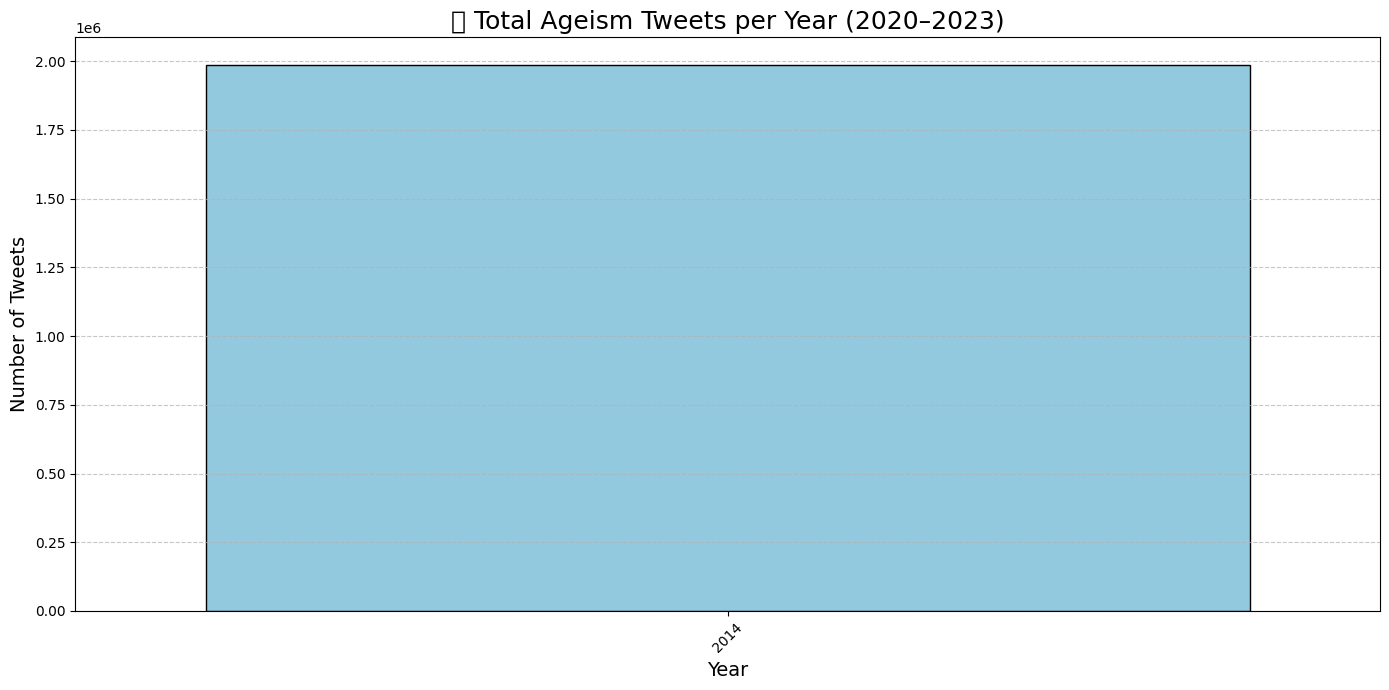

/tmp/ipykernel_2688570/4034436623.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/n/home13/zwang2061/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


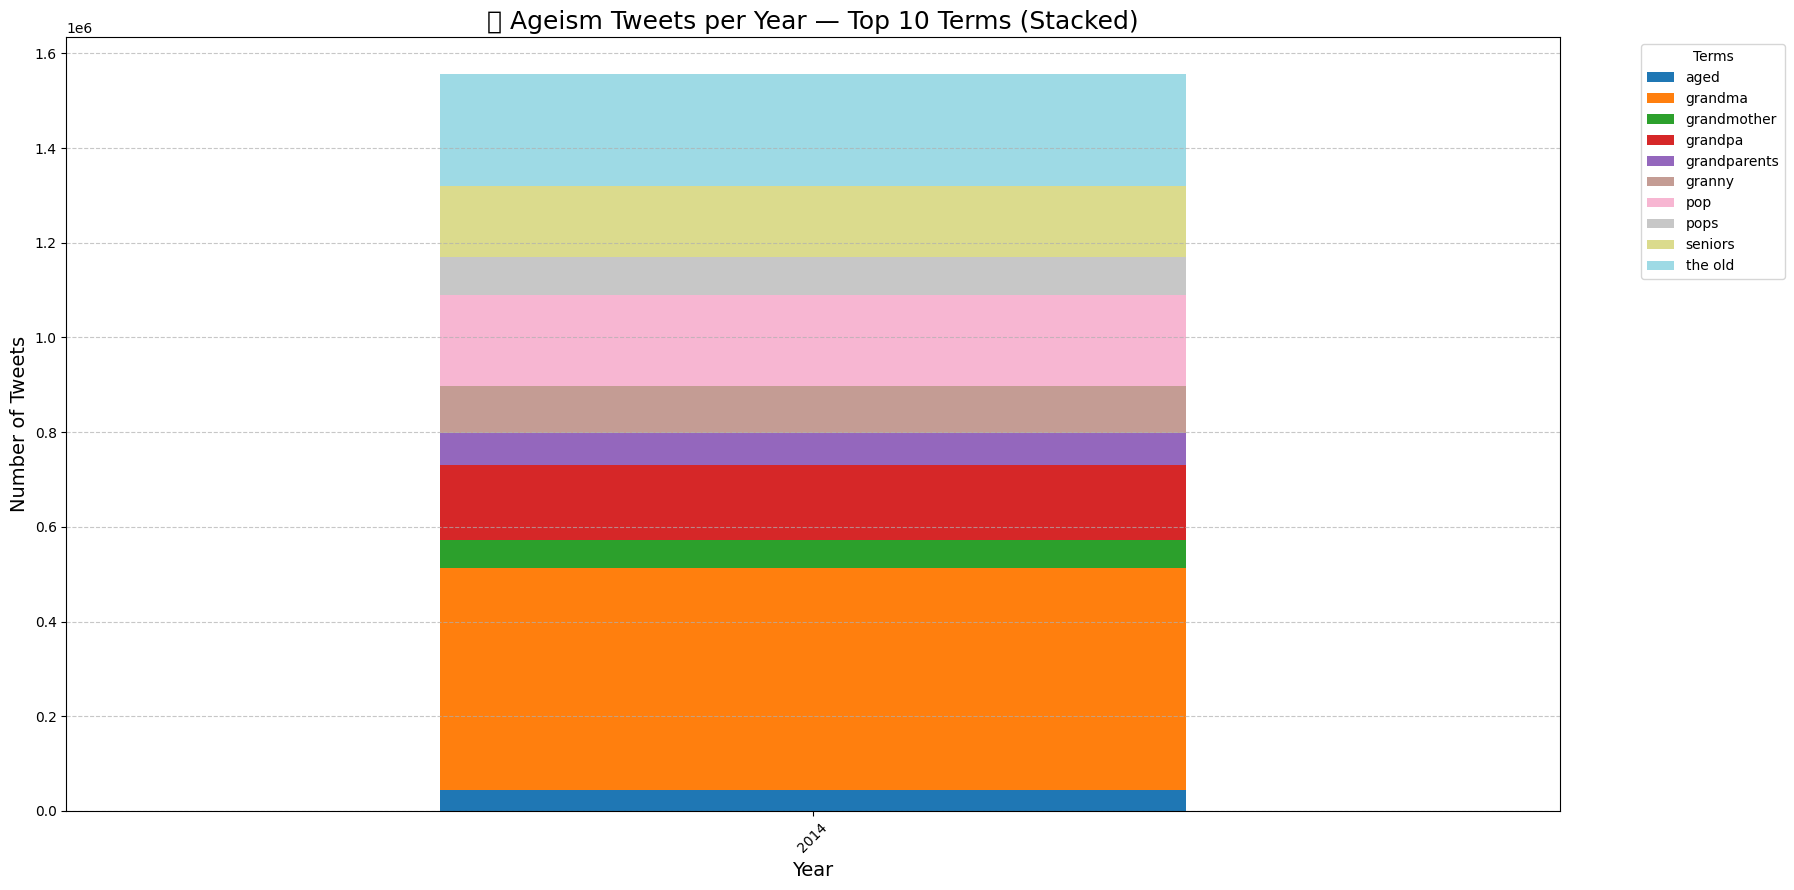


✅ Yearly tweet summary plots generated!


In [24]:
# 🚀 Block 9 — Yearly Tweet Counts and Term Breakdown (Auto-run) — v6

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_FILE = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year.csv")

# -----------------------------
# FUNCTION
# -----------------------------
def plot_yearly_tweet_summary(freq_file):
    print("\n──────────────────────────────────── 📊 PLOTTING YEARLY TWEET COUNTS ─────────────────────────────────────", flush=True)

    try:
        df = pd.read_csv(freq_file, dtype=str)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

        # 📈 1. Total tweets per year
        total_per_year = df.groupby("year")["count"].sum().reset_index()

        plt.figure(figsize=(14, 7))
        sns.barplot(x="year", y="count", data=total_per_year, color="skyblue", edgecolor="black")
        plt.title("📊 Total Ageism Tweets in year 2014", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Number of Tweets", fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

        # 📊 2. Stacked barplot of top 10 terms
        top_terms = df.groupby("term")["count"].sum().nlargest(10).index.tolist()
        df_top = df[df["term"].isin(top_terms)]

        pivot_df = df_top.pivot_table(index="year", columns="term", values="count", fill_value=0)

        pivot_df.plot(kind="bar", stacked=True, figsize=(18, 9), colormap="tab20")
        plt.title("📊 Ageism Tweets per Year — Top 10 Terms (Stacked)", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Number of Tweets", fontsize=14)
        plt.legend(title="Terms", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n✅ Yearly tweet summary plots generated!", flush=True)

    except Exception as e:
        print(f"⚠️ Error plotting yearly tweet summary: {e}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
plot_yearly_tweet_summary(FREQ_FILE)

In [27]:
# 🚀 Block 10 — Geospatial Clustering with HDBSCAN (Auto-run) — v6

import pandas as pd
import numpy as np
import glob
import os
import hdbscan
import folium
from folium.plugins import MarkerCluster

# -----------------------------
# CONFIGURATION
# -----------------------------
CLUSTER_OUTPUT = os.path.join(OUTPUT_DIR, "ageism_cluster_map.html")
MIN_SAMPLES = 10
MIN_CLUSTER_SIZE = 30

# -----------------------------
# FUNCTION
# -----------------------------
def run_spatial_clustering(output_folder):
    print("\n──────────────────────────────────── 🧭 RUNNING GEOSPATIAL CLUSTERING ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if len(coords) < 100:
        print("⚠️ Not enough geolocated tweets for clustering.", flush=True)
        return

    # -----------------------------
    # HDBSCAN Clustering
    # -----------------------------
    coords_np = np.array(coords)
    coords_rad = np.radians(coords_np)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES, metric='haversine')
    labels = clusterer.fit_predict(coords_rad)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"✅ Clustering complete — {n_clusters} clusters found", flush=True)

    # -----------------------------
    # Map Clusters
    # -----------------------------
    m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")
    marker_cluster = MarkerCluster().add_to(m)

    for (lat, lon), label in zip(coords_np, labels):
        color = "gray" if label == -1 else f"#{hash(str(label)) & 0xFFFFFF:06x}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.6,
            popup=f"Cluster {label}" if label != -1 else "Noise"
        ).add_to(marker_cluster)

    m.save(CLUSTER_OUTPUT)
    print(f"\n✅ Cluster map saved to: {CLUSTER_OUTPUT}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
run_spatial_clustering(OUTPUT_DIR)


──────────────────────────────────── 🧭 RUNNING GEOSPATIAL CLUSTERING ─────────────────────────────────────


/n/home13/zwang2061/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


MemoryError: Unable to allocate 512. GiB for an array with shape (262143, 262143) and data type float64

In [28]:
# 🚀 Block 11 — Cluster Statistics Generator (Auto-run) — v6

import pandas as pd
import numpy as np
import glob
import os
import hdbscan

# -----------------------------
# CONFIGURATION
# -----------------------------
CLUSTER_SUMMARY_OUTPUT = os.path.join(OUTPUT_DIR, "ageism_cluster_summary.csv")
MIN_SAMPLES = 10
MIN_CLUSTER_SIZE = 30

# -----------------------------
# FUNCTION
# -----------------------------
def generate_cluster_statistics(output_folder):
    print("\n──────────────────────────────────── 📋 GENERATING CLUSTER STATISTICS ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if len(coords) < 100:
        print("⚠️ Not enough geolocated tweets for cluster stats.", flush=True)
        return

    # -----------------------------
    # Clustering
    # -----------------------------
    coords_np = np.array(coords)
    coords_rad = np.radians(coords_np)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES, metric='haversine')
    labels = clusterer.fit_predict(coords_rad)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"✅ Clustering complete for stats — {n_clusters} clusters detected.", flush=True)

    # -----------------------------
    # Generate Summary
    # -----------------------------
    df_clusters = pd.DataFrame({
        "latitude": coords_np[:, 0],
        "longitude": coords_np[:, 1],
        "cluster": labels
    })

    df_clusters = df_clusters[df_clusters["cluster"] != -1]  # Exclude noise

    summary = df_clusters.groupby("cluster").agg(
        n_tweets=("cluster", "count"),
        centroid_latitude=("latitude", "mean"),
        centroid_longitude=("longitude", "mean")
    ).reset_index()

    summary = summary.sort_values(by="n_tweets", ascending=False)
    summary.to_csv(CLUSTER_SUMMARY_OUTPUT, index=False)

    print(f"\n✅ Cluster summary saved to: {CLUSTER_SUMMARY_OUTPUT}", flush=True)
    print(f"🔢 Total clusters in summary: {len(summary)}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_cluster_statistics(OUTPUT_DIR)


──────────────────────────────────── 📋 GENERATING CLUSTER STATISTICS ─────────────────────────────────────


/n/home13/zwang2061/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


MemoryError: Unable to allocate 512. GiB for an array with shape (262143, 262143) and data type float64

In [ ]:
 🚀 Block 12 — Geolocation-Based Tweet Country Summary (Auto-run) — v6

import pandas as pd
import reverse_geocoder as rg
import pycountry
import os
import glob

# -----------------------------
# CONFIGURATION
# -----------------------------
COUNTRY_SUMMARY_OUTPUT = os.path.join(OUTPUT_DIR, "tweets_by_country.csv")
BATCH_SIZE = 10000

# -----------------------------
# FUNCTION
# -----------------------------
def generate_country_statistics(output_folder):
    print("\n──────────────────────────────────── 🌍 GENERATING TWEETS BY COUNTRY ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if not coords:
        print("⚠️ No coordinates found.", flush=True)
        return

    print(f"🔵 Total coordinates to process: {len(coords):,}", flush=True)

    # -----------------------------
    # Reverse Geocoding in Batches
    # -----------------------------
    results = []
    for i in range(0, len(coords), BATCH_SIZE):
        batch = coords[i:i + BATCH_SIZE]
        batch = [(float(lat), float(lon)) for lat, lon in batch]
        print(f"🌎 Geocoding batch {i // BATCH_SIZE + 1} ({len(batch)} points)...", flush=True)
        results.extend(rg.search(batch, mode=2))

    # Extract country codes
    country_codes = [result["cc"] for result in results]
    df_countries = pd.DataFrame(country_codes, columns=["country_code"])

    summary = df_countries.value_counts().reset_index()
    summary.columns = ["country_code", "n_tweets"]

    # Convert ISO2 to country names
    def get_country_name(code):
        try:
            return pycountry.countries.get(alpha_2=code).name
        except:
            return "Unknown"

    summary["country_name"] = summary["country_code"].apply(get_country_name)
    summary = summary[["country_name", "country_code", "n_tweets"]]
    summary = summary.sort_values(by="n_tweets", ascending=False)

    summary.to_csv(COUNTRY_SUMMARY_OUTPUT, index=False)

    print(f"\n✅ Country summary saved to: {COUNTRY_SUMMARY_OUTPUT}", flush=True)
    print(f"🔢 Total countries detected: {len(summary)}", flush=True)

    print("\n🏆 Top 10 countries by number of tweets:")
    print(summary.head(10).to_string(index=False))

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_country_statistics(OUTPUT_DIR)